In [5]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import platform

# 운영체제별 폰트 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
elif platform.system() == 'Darwin': # Mac
    plt.rc('font', family='AppleGothic')
else: # Linux (Colab 등)
    plt.rc('font', family='NanumGothic')

df = pd.read_csv('data/real_estate_clean_v1.csv',encoding='cp949')
df

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_64553/129409565.py:14: DtypeWarning: Columns (14) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('data/real_estate_clean_v1.csv',encoding='cp949')


,Unnamed: 0,CGG_CD,CGG_NM,STDG_CD,STDG_NM,BLDG_NM,CTRT_DAY,THING_AMT,ARCH_AREA,LAND_AREA,FLR,RGHT_SE,ARCH_YR,BLDG_USG,DCLR_SE,CTRT_YEAR
0,0,11500,강서구,10300,화곡동,"우장산아이파크,이편한세상",2019-04-25,95000,101.65,NaN,10.0,NaN,2008,아파트,NaN,2019
1,1,11410,서대문구,11200,대현동,럭키대현,2019-03-16,70000,83.38,NaN,10.0,NaN,1999,아파트,NaN,2019
2,2,11590,동작구,10700,사당동,현대,2019-02-21,49500,51.66,NaN,10.0,NaN,1991,아파트,NaN,2019
3,3,11350,노원구,10500,상계동,초산빌라,2019-01-21,16000,41.37,18.38,1.0,NaN,1996,연립다세대,NaN,2019
4,4,11380,은평구,11000,증산동,궁전맨션(189-63),2019-01-03,43000,54.34,27.17,2.0,NaN,1992,연립다세대,NaN,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
794601,833594,11740,강동구,10900,천호동,경복빌라,2023-11-21,28500,44.11,32.99,1.0,NaN,1991,연립다세대,중개거래,2023
794602,833595,11215,광진구,10700,화양동,KCC파크타운,2023-11-14,19000,25.79,37.36,14.0,NaN,2005,오피스텔,중개거래,2023
794603,833596,11440,마포구,12200,합정동,그레이스빌2차A,2023-11-13,26300,22.44,12.65,5.0,NaN,2004,연립다세대,직거래,2023
794604,833597,11440,마포구,12600,중동,백명TRENDYAPT,2023-11-11,76000,107.48,0.00,6.0,NaN,2004,아파트,중개거래,2023


### 브레인스토밍
평당가를 구했어. 그걸로 뭐해? 지역별로 평당가를 보는거야. 평당가가 어떻게 변하는지를 보자 같은 구 내에서. 그럼 가격변화를 알 수 있는거잖아. 가격변화가 어떠한지 
평당가가 자치구별로 어떻게 차이가 나는지. 그리고 그걸 연평균 증가율이 어떠한지 확인.

# 1인가구 증가한다며 요즘

In [21]:
group = df['BLDG_USG'].value_counts()
group

BLDG_USG
아파트      375767
연립다세대    279723
오피스텔      86005
단독다가구     53111
Name: count, dtype: int64

In [22]:
target_usg = ['아파트', '오피스텔', '연립다세대', '단독다가구']

df_plot = df[df['BLDG_USG'].isin(target_usg)].copy()

In [ ]:
avg_price = (
    df_plot
    .groupby(['CTRT_YEAR', 'BLDG_USG'])['THING_AMT']
    .mean()
    .reset_index()
)

In [ ]:
plt.figure(figsize=(10, 6))

for usg in target_usg:
    data = avg_price[avg_price['BLDG_USG'] == usg]
    plt.plot(
        data['CTRT_YEAR'],
        data['THING_AMT'],
        marker='o',
        label=usg
    )

plt.grid(True)

plt.show()

In [ ]:
group = df.groupby('BLDG_USG')

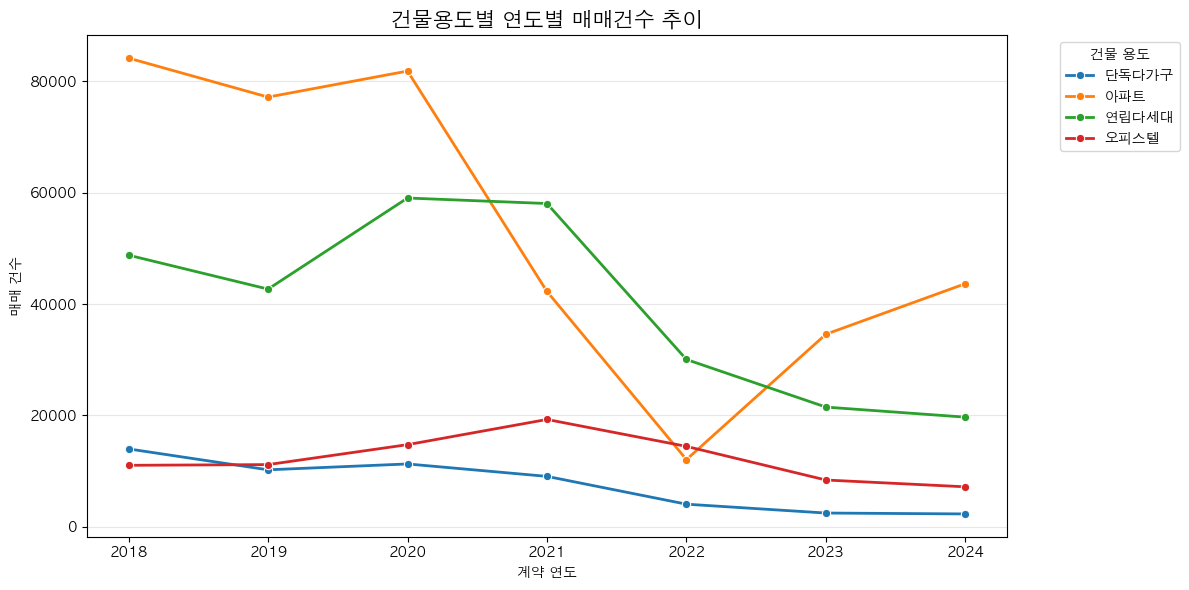

In [24]:
# 2. 연도별, 건물용도별 거래건수 집계
df_trend = df.groupby(['CTRT_YEAR', 'BLDG_USG']).size().reset_index(name='count')

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trend, x='CTRT_YEAR', y='count', hue='BLDG_USG', marker='o', linewidth=2)

plt.title('건물용도별 연도별 매매건수 추이', fontsize=15)
plt.xlabel('계약 연도')
plt.ylabel('매매 건수')
plt.legend(title='건물 용도', bbox_to_anchor=(1.05, 1), loc='upper left') # 범례를 그래프 밖으로
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

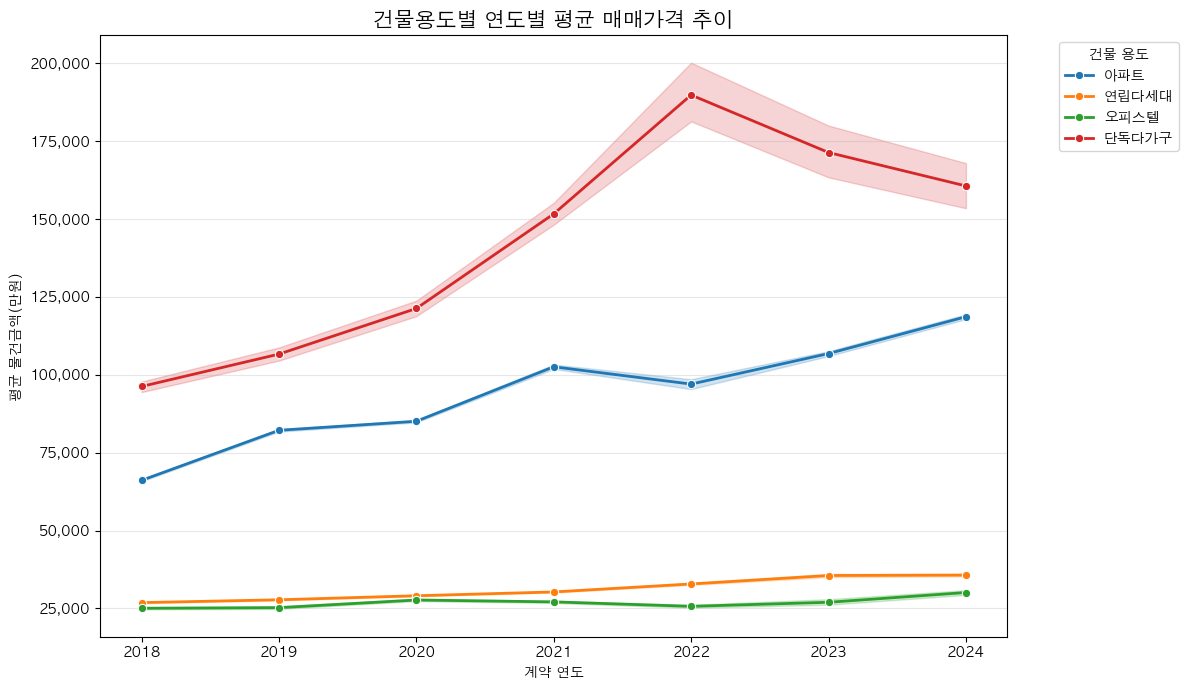

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))

# estimator=np.median 을 사용하면 평균 대신 중앙값으로 그릴 수 있습니다.
# 여기서는 일반적인 경향성을 보기 위해 평균(기본값)을 사용하되, 
# 고가 매물 영향을 줄이려면 np.median을 고려해 보세요.
sns.lineplot(data=df, x='CTRT_YEAR', y='THING_AMT', hue='BLDG_USG', 
             marker='o', err_style='band', linewidth=2)

plt.title('건물용도별 연도별 평균 매매가격 추이', fontsize=15)
plt.xlabel('계약 연도')
plt.ylabel('평균 물건금액(만원)')
plt.legend(title='건물 용도', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)

# 천단위 구분 기호 추가 (금액 읽기 편하게)
from matplotlib.ticker import FuncFormatter
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

plt.tight_layout()
plt.show()

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_64553/919418523.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=apt_data, x='CTRT_YEAR', y='THING_AMT', palette='viridis')


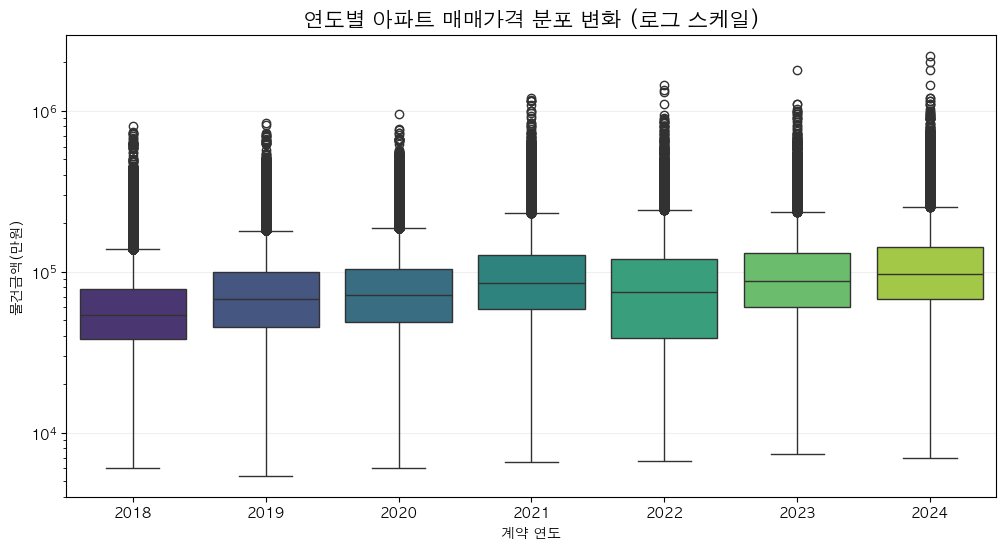

In [28]:
# 아파트 데이터만 따로 뽑아서 연도별 가격 분포 변화 확인
apt_data = df[df['BLDG_USG'] == '아파트']

plt.figure(figsize=(12, 6))
sns.boxplot(data=apt_data, x='CTRT_YEAR', y='THING_AMT', palette='viridis')

plt.yscale('log') # 가격 편차가 크므로 로그 스케일 권장
plt.title('연도별 아파트 매매가격 분포 변화 (로그 스케일)', fontsize=15)
plt.xlabel('계약 연도')
plt.ylabel('물건금액(만원)')
plt.grid(True, axis='y', alpha=0.2)
plt.show()

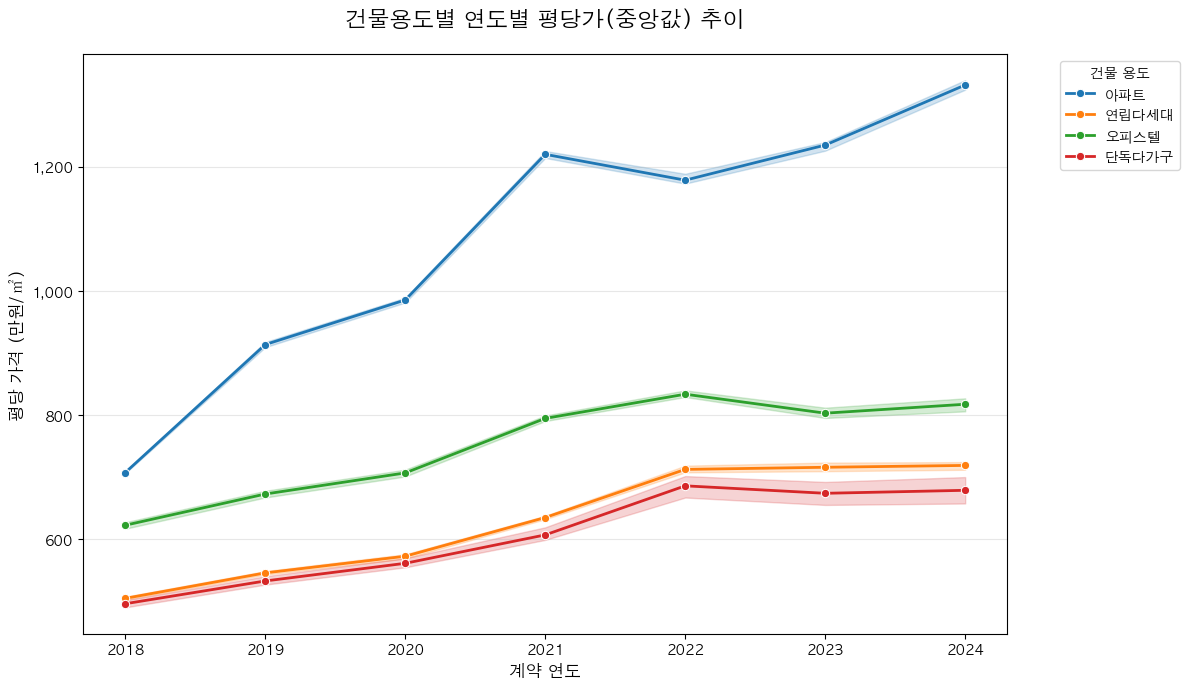

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter

# 그래프 스타일 설정
plt.figure(figsize=(12, 7))

# 평당가 추이 lineplot
# 고가 매물에 의한 왜곡을 줄이기 위해 중앙값(median)을 사용하는 것을 추천합니다.
sns.lineplot(data=df, x='CTRT_YEAR', y='price_per_area', hue='BLDG_USG', 
             marker='o', linewidth=2, estimator=np.median, errorbar=('ci', 95))

# 그래프 제목 및 축 라벨
plt.title('건물용도별 연도별 평당가(중앙값) 추이', fontsize=16, pad=20)
plt.xlabel('계약 연도', fontsize=12)
plt.ylabel('평당 가격 (만원/㎡)', fontsize=12)

# y축 천단위 콤마 포맷팅
plt.gca().yaxis.set_major_formatter(FuncFormatter(lambda x, p: format(int(x), ',')))

# 범례 설정
plt.legend(title='건물 용도', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

plt.show()

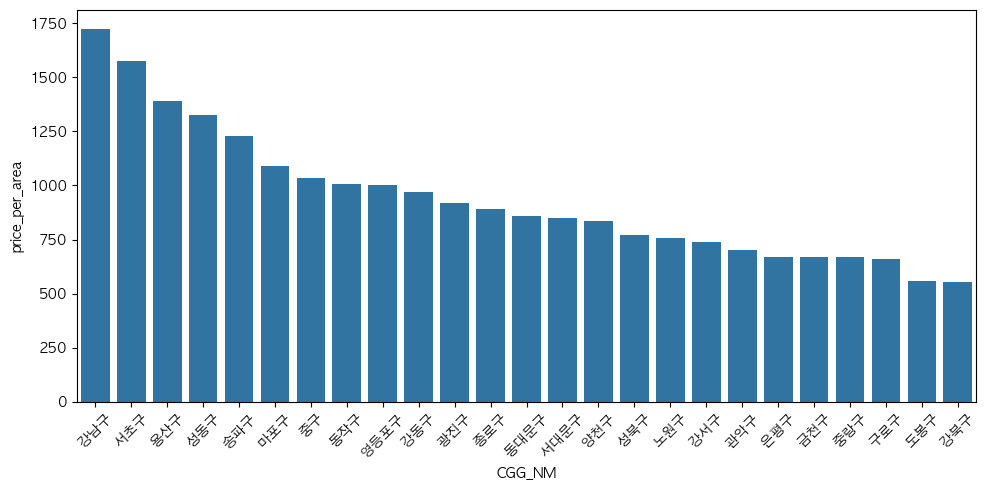

In [9]:
df['price_per_area'] = df['THING_AMT'] / df['ARCH_AREA']
cgg = df.groupby('CGG_NM',as_index=False)['price_per_area'].mean().sort_values(by='price_per_area',ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=cgg, x='CGG_NM',y='price_per_area')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

In [12]:
cgg.describe()

,price_per_area
count,25.000000
mean,938.430634
std,308.137871
min,555.461632
25%,702.454529
50%,860.532866
75%,1036.715467
max,1725.746686


In [14]:
q3 = cgg['price_per_area'].quantile(0.75) 
cgg[cgg['price_per_area']>q3]

,CGG_NM,price_per_area
0,강남구,1725.746686
14,서초구,1576.726758
20,용산구,1392.458707
15,성동구,1324.453155
17,송파구,1229.987132
12,마포구,1088.914715


In [15]:
gangnam = df[df['CGG_NM']=='강남구']
seocho = df[df['CGG_NM']=='서초구']
yongsan = df[df['CGG_NM']=='용산구']
seongdong = df[df['CGG_NM']=='성동구']
songpa = df[df['CGG_NM']=='송파구']
mapo = df[df['CGG_NM']=='마포구']

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_64553/2655338507.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gangnam['price_per_area'] = gangnam['THING_AMT'] / gangnam['ARCH_AREA']


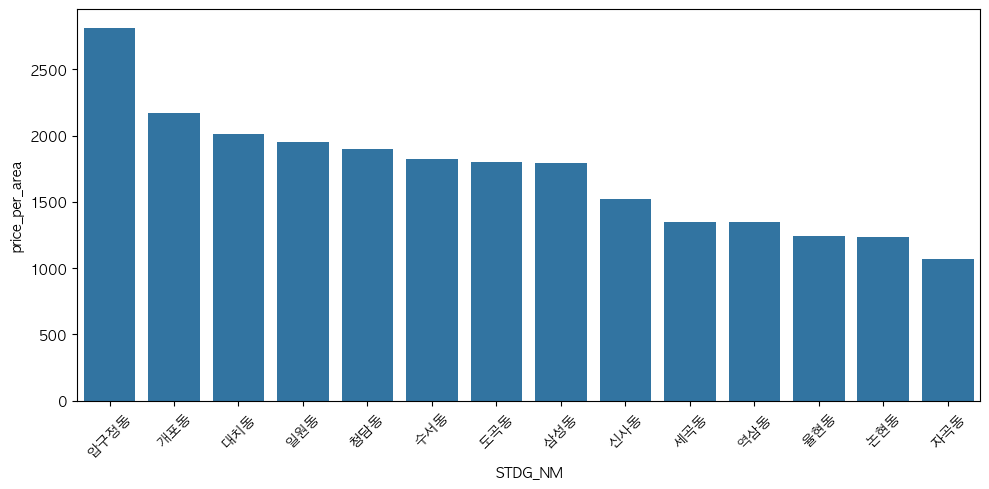

In [16]:
gangnam['price_per_area'] = gangnam['THING_AMT'] / gangnam['ARCH_AREA']
stdg = gangnam.groupby('STDG_NM',as_index=False)['price_per_area'].mean().sort_values(by='price_per_area',ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=stdg, x='STDG_NM',y='price_per_area')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_64553/915771703.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  seocho['price_per_area'] = seocho['THING_AMT'] / seocho['ARCH_AREA']


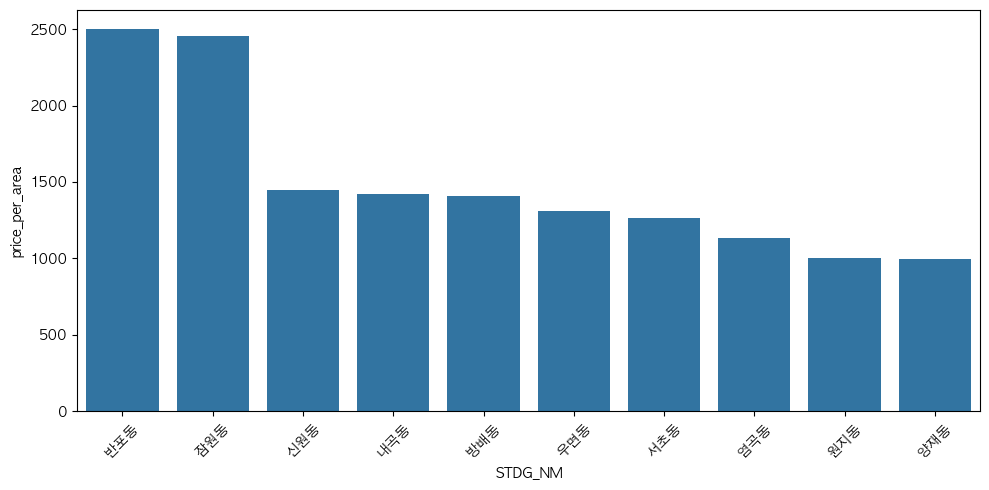

In [17]:
seocho['price_per_area'] = seocho['THING_AMT'] / seocho['ARCH_AREA']
stdg = seocho.groupby('STDG_NM',as_index=False)['price_per_area'].mean().sort_values(by='price_per_area',ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=stdg, x='STDG_NM',y='price_per_area')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

/var/folders/s9/dc7mvn1n1nl45gw342h0m_kr0000gn/T/ipykernel_64553/882075254.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  yongsan['price_per_area'] = yongsan['THING_AMT'] / yongsan['ARCH_AREA']


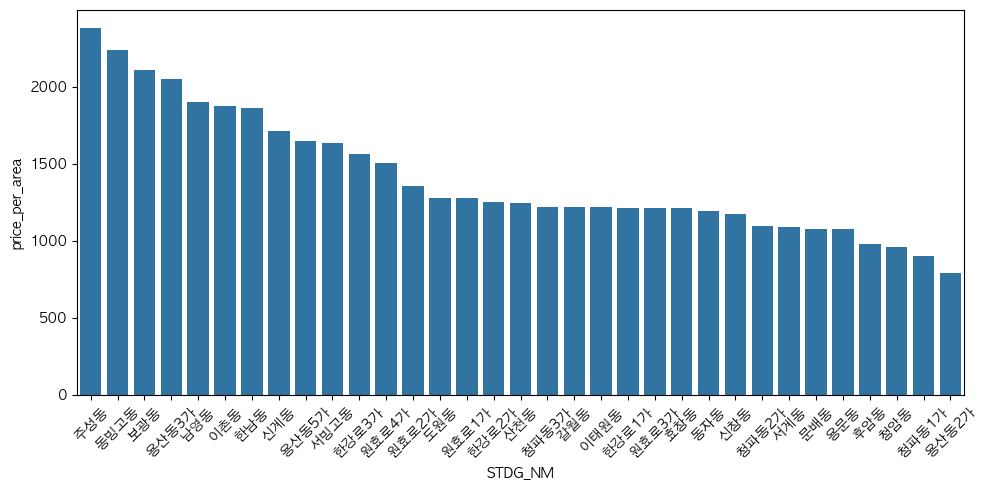

In [18]:
yongsan['price_per_area'] = yongsan['THING_AMT'] / yongsan['ARCH_AREA']
stdg = yongsan.groupby('STDG_NM',as_index=False)['price_per_area'].mean().sort_values(by='price_per_area',ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=stdg, x='STDG_NM',y='price_per_area')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

yongsan['price_per_area'] = gangnam['THING_AMT'] / gangnam['ARCH_AREA']
stdg = gangnam.groupby('STDG_NM',as_index=False)['price_per_area'].mean().sort_values(by='price_per_area',ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=stdg, x='STDG_NM',y='price_per_area')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()

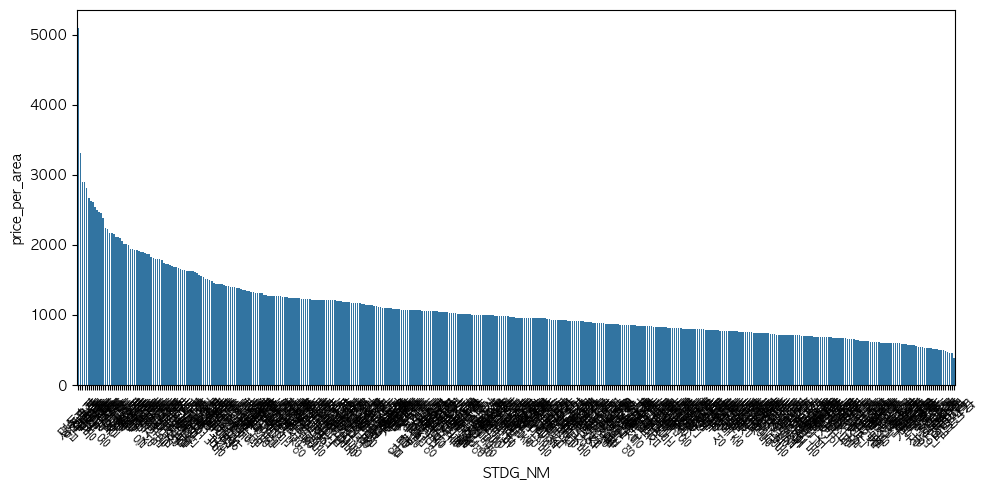

In [11]:
df['price_per_area'] = df['THING_AMT'] / df['ARCH_AREA']
stdg = df.groupby('STDG_NM',as_index=False)['price_per_area'].mean().sort_values(by='price_per_area',ascending=False)
plt.figure(figsize=(10,5))
sns.barplot(data=stdg, x='STDG_NM',y='price_per_area')
plt.xticks(rotation=45)
plt.tight_layout() 
plt.show()